In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# EDA

In [2]:
df = pd.read_csv('data/rankedrm.csv', encoding='latin-1')

In [3]:
df.head()

,match_uuid,started,finished,map_type,steam_id.win,name.win,country.win,rating.win,rating_change.win,civ.win,...,country.lose,rating.lose,rating_change.lose,civ.lose,color.lose,map_type.name,civ.lose.name,civ.win.name,matchup,duration
0,004b580b-dd9f-2841-a771-3693b41d7361,2021-03-01 00:00:14,2021-03-01 00:28:25,9,7.656120e+16,Uwiza,GB,1101.0,16.0,11,...,NaN,1107.0,-16.0,12,3.0,Arabia,Goths,Franks,Franks-Goths,00:28:11
1,a20d7ab9-e240-6f45-9f8e-a2f5d7641558,2021-03-01 00:00:24,2021-03-01 00:27:01,19,7.656120e+16,[DaRs] Chirris_,MX,1671.0,NaN,27,...,GT,1680.0,NaN,28,1.0,Islands,Saracens,Portuguese,Portuguese-Saracens,00:26:37
2,c1407700-1238-3d47-b5d3-a40cbc9a9722,2021-03-01 00:00:30,2021-03-01 00:42:56,9,7.656120e+16,Frigma,CL,1254.0,16.0,19,...,GB,1268.0,-16.0,2,1.0,Arabia,Britons,Koreans,Britons-Koreans,00:42:26
3,1bdb9e60-81e6-514c-80fa-a2a56eed3e16,2021-03-01 00:00:26,2021-03-01 00:32:57,9,7.656120e+16,doctora Chinda Brandolino,AR,803.0,17.0,9,...,NaN,825.0,NaN,26,1.0,Arabia,Persians,Cumans,Cumans-Persians,00:32:31
4,12b09879-24b7-0049-a0b4-14dce9fe1950,2021-03-01 00:00:55,2021-03-01 00:44:07,16,NaN,PrecedentSolid4,NaN,661.0,33.0,11,...,CL,601.0,-22.0,16,1.0,Fortress,Italians,Franks,Franks-Italians,00:43:12


In [4]:
len(df)

105624

In [5]:
df.dtypes

match_uuid             object
started                object
finished               object
map_type                int64
steam_id.win          float64
name.win               object
country.win            object
rating.win            float64
rating_change.win     float64
civ.win                 int64
color.win             float64
steam_id.lose         float64
name.lose              object
country.lose           object
rating.lose           float64
rating_change.lose    float64
civ.lose                int64
color.lose            float64
map_type.name          object
civ.lose.name          object
civ.win.name           object
matchup                object
duration               object
dtype: object

First I'll rename the columns:

In [6]:
df = df.rename(
    columns={
        "steam_id.win": "steam_id_win", 
        "name.win": "name_win", 
        "country.win": "country_win",
        "rating.win": "rating_win",
        "rating_change.win": "rating_change_win",
        "civ.win": "civ_win",
        "color.win": "color_win",
        "steam_id.lose": "steam_id_lose",
        "name.lose": "name_lose",
        "country.lose": "country_lose",
        "rating.lose": "rating_lose",
        "rating_change.lose": "rating_change_lose",
        "civ.lose": "civ_lose",
        "color.lose": "color_lose",
        "map_type.name": "map_type_name",
        "civ.lose.name": "civ_lose_name",
        "civ.win.name": "civ_win_name"
})


In [7]:
df.dtypes

match_uuid             object
started                object
finished               object
map_type                int64
steam_id_win          float64
name_win               object
country_win            object
rating_win            float64
rating_change_win     float64
civ_win                 int64
color_win             float64
steam_id_lose         float64
name_lose              object
country_lose           object
rating_lose           float64
rating_change_lose    float64
civ_lose                int64
color_lose            float64
map_type_name          object
civ_lose_name          object
civ_win_name           object
matchup                object
duration               object
dtype: object

In [8]:
df.isnull().sum()

match_uuid                0
started                   0
finished                  0
map_type                  0
steam_id_win           6760
name_win                  2
country_win            6784
rating_win             4295
rating_change_win     38942
civ_win                   0
color_win                 4
steam_id_lose          7184
name_lose                 2
country_lose           7211
rating_lose            8214
rating_change_lose    42244
civ_lose                  0
color_lose                6
map_type_name             0
civ_lose_name             0
civ_win_name              0
matchup                   0
duration                  0
dtype: int64

Next, I'll exclude some columns that I don't find that relevant

In [9]:
columns_to_exclude = ['steam_id_win', 'name_win', 'rating_change_win', 'color_win', 'steam_id_lose', 'name_lose', 'rating_change_lose', 'color_lose']
df = df.loc[:, ~df.columns.isin(columns_to_exclude)]

These are the columns I'll be using:

In [10]:
df.isnull().sum()

match_uuid          0
started             0
finished            0
map_type            0
country_win      6784
rating_win       4295
civ_win             0
country_lose     7211
rating_lose      8214
civ_lose            0
map_type_name       0
civ_lose_name       0
civ_win_name        0
matchup             0
duration            0
dtype: int64

I'll use the mean for the rating of the winner and the rating of the loser:

In [11]:
df.rating_win = df.rating_win.fillna(df.rating_win.mean())
df.rating_lose = df.rating_lose.fillna(df.rating_lose.mean())

In [12]:
df.isnull().sum()

match_uuid          0
started             0
finished            0
map_type            0
country_win      6784
rating_win          0
civ_win             0
country_lose     7211
rating_lose         0
civ_lose            0
map_type_name       0
civ_lose_name       0
civ_win_name        0
matchup             0
duration            0
dtype: int64

I'll drop the nulls for the countries:

In [13]:
df_clean = df.dropna()

In [14]:
len(df_clean)

92304

Checking the unique values:

/var/folders/km/dql4gckx6ps4lrl0mdrhnsbh0000gn/T/ipykernel_83586/2480019187.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(columns, rotation=45, ha='right')


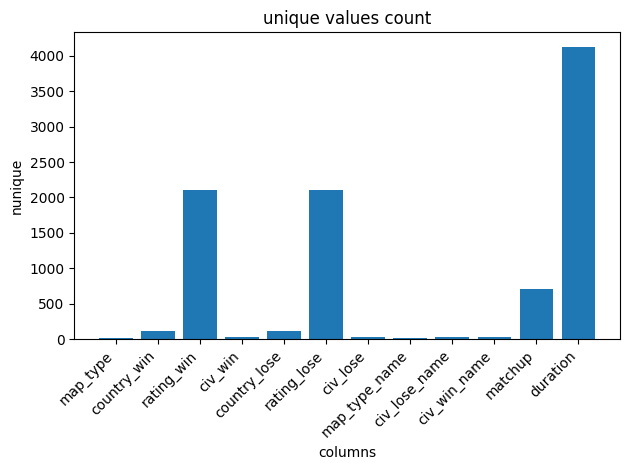

In [15]:
columns = []
unique_values_count = []
for col in df_clean.columns:
    if col not in ['match_uuid', 'started', 'finished']:
        columns.append(col)
        unique_values_count.append(df_clean[col].nunique())

fig, ax = plt.subplots()
ax.bar(columns, unique_values_count)
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.set_xlabel("columns")
ax.set_ylabel("nunique")
ax.set_title("unique values count")

plt.tight_layout()
plt.show()

In [16]:
for i in range(len(columns)):
    print(columns[i], ":", unique_values_count[i])

map_type : 12
country_win : 122
rating_win : 2101
civ_win : 37
country_lose : 121
rating_lose : 2111
civ_lose : 37
map_type_name : 12
civ_lose_name : 37
civ_win_name : 37
matchup : 703
duration : 4124


I'll tweak the dataset so that instead of having winer and loser columns, I'll have player 1 and player 2. And I'll add a traget columns.

I'll also duplicate the data to have one dataset where the player 1 wins and other where the player 1 loses. Combine and shuffle the data.

In [17]:
# --- P1 = winner ---
p1_win = pd.DataFrame({
    "civ_p1": df_clean["civ_win"],
    "civ_p2": df_clean["civ_lose"],
    "rating_p1": df_clean["rating_win"],
    "rating_p2": df_clean["rating_lose"],
    "country_p1": df_clean["country_win"],
    "country_p2": df_clean["country_lose"],
    "map_type": df_clean["map_type"],
    "map_type_name": df_clean["map_type_name"],
    "duration": df_clean["duration"],
    "target": 1
})

# --- P1 = loser ---
p1_lose = pd.DataFrame({
    "civ_p1": df_clean["civ_lose"],
    "civ_p2": df_clean["civ_win"],
    "rating_p1": df_clean["rating_lose"],
    "rating_p2": df_clean["rating_win"],
    "country_p1": df_clean["country_lose"],
    "country_p2": df_clean["country_win"],
    "map_type": df_clean["map_type"],
    "map_type_name": df_clean["map_type_name"],
    "duration": df_clean["duration"],
    "target": 0
})

# Combine the datasets
df_clean = pd.concat([p1_win, p1_lose], ignore_index=True)

# Shuffle
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

## Feature Engineering

Let's just add a ratting diff column:

In [18]:
# Small feature engineering
df_clean["rating_diff"] = df_clean["rating_p1"] - df_clean["rating_p2"]

In [19]:
df_clean.head()

,civ_p1,civ_p2,rating_p1,rating_p2,country_p1,country_p2,map_type,map_type_name,duration,target,rating_diff
0,8,29,1486.0,1490.0,US,PE,9,Arabia,00:18:33,0,-4.0
1,10,24,1293.0,1328.0,PT,US,9,Arabia,00:29:38,0,-35.0
2,3,19,1057.0,1058.0,ES,SE,150,Atacama,00:23:39,1,-1.0
3,11,25,1250.0,1249.0,AR,US,9,Arabia,00:23:34,1,1.0
4,6,13,1007.0,1015.0,US,TW,77,MegaRandom,00:29:00,1,-8.0


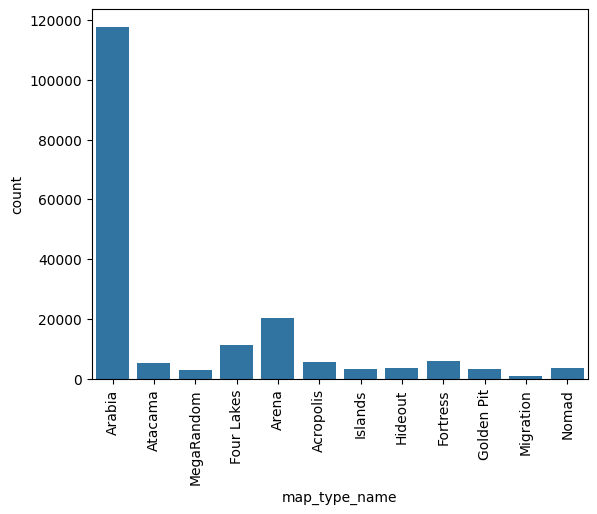

In [20]:
sns.countplot(data=df_clean, x='map_type_name')
plt.xticks(rotation=90)
plt.show()

Arabia is the most common map.

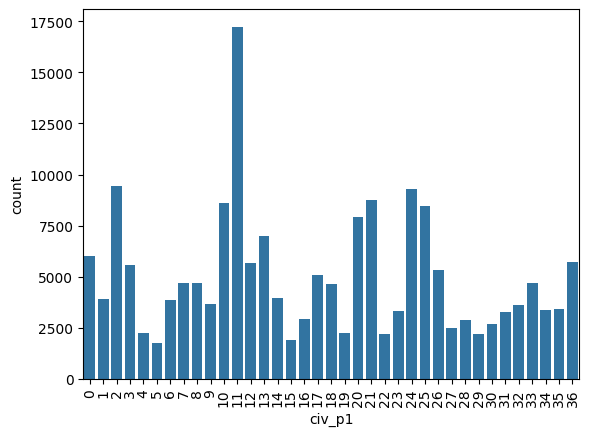

In [21]:
sns.countplot(data=df_clean, x='civ_p1')
plt.xticks(rotation=90)
plt.show()

In [22]:
for i in range(37):
    print(i, "->", df[df['civ_win'] == i].civ_win_name.iloc[0])

0 -> Aztecs
1 -> Berbers
2 -> Britons
3 -> Bulgarians
4 -> Burgundians
5 -> Burmese
6 -> Byzantines
7 -> Celts
8 -> Chinese
9 -> Cumans
10 -> Ethiopians
11 -> Franks
12 -> Goths
13 -> Huns
14 -> Incas
15 -> Indians
16 -> Italians
17 -> Japanese
18 -> Khmer
19 -> Koreans
20 -> Lithuanians
21 -> Magyars
22 -> Malay
23 -> Malians
24 -> Mayans
25 -> Mongols
26 -> Persians
27 -> Portuguese
28 -> Saracens
29 -> Sicilians
30 -> Slavs
31 -> Spanish
32 -> Tatars
33 -> Teutons
34 -> Turks
35 -> Vietnamese
36 -> Vikings


And the Franks is the most common civilization.

In [23]:
numerical_features = list(df_clean.dtypes[df_clean.dtypes != 'object'].keys())
numerical_features = [feat for feat in numerical_features if feat not in ['match_id'] ]
numerical_features

['civ_p1',
 'civ_p2',
 'rating_p1',
 'rating_p2',
 'map_type',
 'target',
 'rating_diff']

In [24]:
correlations = {k: [] for k in numerical_features }

for col in numerical_features:
    for col2 in numerical_features:
        correlations[col].append(df_clean[col].corr(df_clean[col2]).round(7)) 

correlation_matrix = pd.DataFrame(correlations)
correlation_matrix.index = numerical_features

correlation_matrix

,civ_p1,civ_p2,rating_p1,rating_p2,map_type,target,rating_diff
civ_p1,1.000000,0.029768,0.026822,0.027165,0.008974,-0.005609,-0.001078
civ_p2,0.029768,1.000000,0.027165,0.026822,0.008974,0.005609,0.001078
rating_p1,0.026822,0.027165,1.000000,0.949676,-0.127694,0.005227,0.158625
rating_p2,0.027165,0.026822,0.949676,1.000000,-0.127694,-0.005227,-0.158625
map_type,0.008974,0.008974,-0.127694,-0.127694,1.000000,0.000000,-0.000000
target,-0.005609,0.005609,0.005227,-0.005227,0.000000,1.000000,0.032950
rating_diff,-0.001078,0.001078,0.158625,-0.158625,-0.000000,0.032950,1.000000


Here the rating_diff, civlizations and ratings have have more correlation with the target. The map_type doesn't have much correlation.

In [25]:
categorical_features = list(df_clean.dtypes[df_clean.dtypes == 'object'].keys())
categorical_features

['country_p1', 'country_p2', 'map_type_name', 'duration']

In [26]:
from sklearn.metrics import mutual_info_score

In [27]:
mi = df_clean[categorical_features].apply(lambda s: mutual_info_score(s, df_clean.target))
mi.sort_values(ascending = False)

country_p1       3.684903e-04
country_p2       3.684903e-04
map_type_name    1.110223e-15
duration         0.000000e+00
dtype: float64

In [28]:
mi = df_clean[categorical_features].apply(lambda s: round(mutual_info_score(s, df_clean.target), 7))
mi.sort_values(ascending = False)

country_p1       0.000369
country_p2       0.000369
map_type_name    0.000000
duration         0.000000
dtype: float64

The country of the players seems to have some relation with the target.

# Validation Framework

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
df_full_train, df_test = train_test_split(df_clean, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
y_full_train = df_full_train.target
y_test = df_test.target
y_train = df_train.target
y_val = df_val.target

df_full_train = df_full_train.drop(columns=['target'])
df_train = df_train.drop(columns=['target'])
df_val = df_val.drop(columns=['target'])

# Model training

## Logistic Regression

In [31]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [32]:
numerical_features = list(df_train.dtypes[df_train.dtypes != 'object'].keys())
categorical_features = list(df_clean.dtypes[df_clean.dtypes == 'object'].keys())

In [33]:
dicts = df_train[categorical_features + numerical_features].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dicts)
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
dicts = df_val[categorical_features + numerical_features].to_dict(orient='records')
X_val = dv.transform(dicts)
y_pred = model.predict(X_val)
round((y_val == y_pred).mean(), 2)

np.float64(0.45)

In [35]:
roc_auc_score(y_val, y_pred)

0.4507715671916296

Ok 45% is not that good...

In [36]:
# dicts = df_train[categorical_features + numerical_features].to_dict(orient='records')
# dv = DictVectorizer(sparse=False)
# X_train = dv.fit_transform(dicts)
# model = LogisticRegression(solver='saga', C=1.0, max_iter=1000, random_state=42)
# model.fit(X_train, y_train)

In [37]:
# dicts = df_val[categorical_features + numerical_features].to_dict(orient='records')
# X_val = dv.transform(dicts)
# y_pred = model.predict(X_val)
# round((y_val == y_pred).mean(), 2)

In [38]:
# roc_auc_score(y_val, y_pred)

In [39]:
dicts = df_train[categorical_features + numerical_features].to_dict(orient='records')
X_train = dv.fit_transform(dicts)
model.fit(X_train, y_train)

dicts = df_val[categorical_features + numerical_features].to_dict(orient='records')
X_val = dv.transform(dicts)
y_pred = model.predict(X_val)
original_accuracy = (y_val == y_pred).mean()
print('Original:', original_accuracy)

for f in categorical_features + numerical_features:
    smaller_features = [feature for feature in categorical_features + numerical_features if feature != f]
    dicts_smaller = df_train[smaller_features].to_dict(orient='records')
    X_train = dv.fit_transform(dicts_smaller)
    model.fit(X_train, y_train)

    dicts = df_val[smaller_features].to_dict(orient='records')
    X_val = dv.transform(dicts)
    y_pred = model.predict(X_val)
    print(f'Without {f} difference:', original_accuracy - (y_val == y_pred).mean())

Original: 0.45078814798764966
Without country_p1 difference: 0.0023021504793889758
Without country_p2 difference: 0.0019500568766589454
Without map_type_name difference: 0.000893776068468688
Without duration difference: -0.06919993499810406
Without civ_p1 difference: -0.0010833649314771487
Without civ_p2 difference: 0.0005416824657386021
Without rating_p1 difference: 0.0002437571095823543
Without rating_p2 difference: 8.125236986078477e-05
Without map_type difference: -0.00018958886300846078
Without rating_diff difference: -0.00018958886300846078


Here the map_type_name as well as the map_type don't seem to bee that important.

Let's try with different regularization parameter values:

In [46]:
for C in [0.00000001, 0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    dicts = df_train[categorical_features + numerical_features].to_dict(orient='records')
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(solver='liblinear', C=C, random_state=42)
    model.fit(X_train, y_train)

    dicts = df_val[categorical_features + numerical_features].to_dict(orient='records')
    X_val = dv.transform(dicts)
    y_pred = model.predict(X_val)
    accuracy = round((y_val == y_pred).mean(), 3)
    score = roc_auc_score(y_val, y_pred)
    print(f"{C}:", accuracy, score)

1e-08: 0.588 0.587591703800451
1e-07: 0.587 0.5868799598924612
1e-06: 0.581 0.5806937605383227
1e-05: 0.577 0.5766941626465624
0.0001: 0.572 0.5722407082597916
0.001: 0.543 0.5433543456210694
0.01: 0.509 0.508826105674421
0.1: 0.465 0.4645160634377978
1: 0.451 0.4507715671916296
10: 0.45 0.4494982919202535
100: 0.449 0.44917267051279014


Here, lowering the C values give us a better result

## Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
dicts = df_train[categorical_features + numerical_features].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dicts)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
dicts = df_val[categorical_features + numerical_features].to_dict(orient='records')
X_val = dv.transform(dicts)
y_pred = dt.predict(X_val)
round((y_val == y_pred).mean(), 2)

np.float64(0.6)

In [51]:
roc_auc_score(y_val, y_pred)

0.60455048383269

Using a Decision Tree Classifier works better for this dataset.

Let's tweak the max_depth value:

In [55]:
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)

    y_pred = dt.predict(X_train)
    auc_train = roc_auc_score(y_train, y_pred)

    print('%4s -> %.3f -> %.3f' % (d, auc, auc_train))

   1 -> 0.590 -> 0.589
   2 -> 0.590 -> 0.589
   3 -> 0.646 -> 0.645
   4 -> 0.646 -> 0.645
   5 -> 0.649 -> 0.649
   6 -> 0.650 -> 0.651
  10 -> 0.648 -> 0.658
  15 -> 0.642 -> 0.677
  20 -> 0.637 -> 0.707
None -> 0.606 -> 1.000


Using a max_depth of 6 gives us the best result.

Let's try with different values for min_samples_leaf

In [56]:
from tqdm import tqdm

In [57]:
scores = []

for d in tqdm([5, 6, 10]):
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict(X_val)
        auc = roc_auc_score(y_val, y_pred)

        scores.append([d, s, auc])

df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores.sort_values(by='auc', ascending=False)

100%|██████████| 3/3 [07:55<00:00, 158.59s/it]


,max_depth,min_samples_leaf,auc
13,6,15,0.650277
12,6,10,0.650277
14,6,20,0.650249
10,6,2,0.650089
9,6,1,0.650089
11,6,5,0.650062
15,6,100,0.649197
6,5,100,0.649136
5,5,20,0.649112
1,5,2,0.649084


Ok, using a max_depth of 6 and min_samples_leaf of

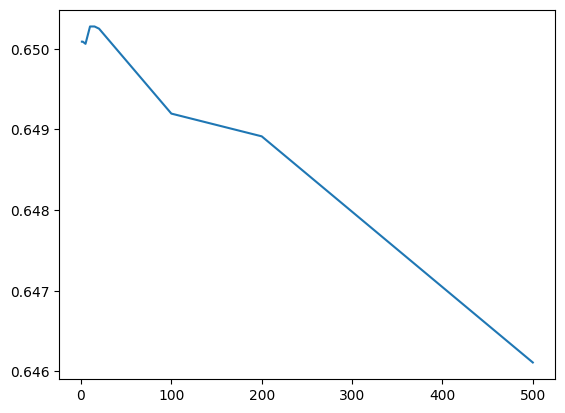

In [79]:
plt.plot(df_scores[df_scores.max_depth == 6].min_samples_leaf, df_scores[df_scores.max_depth == 6].auc)

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
y_pred = rf.predict(X_val)
roc_auc_score(y_val, y_pred)

0.619498391097563

In [84]:
scores = []

for n in tqdm(range(10, 201, 10)):
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

df_scores = pd.DataFrame(scores, columns=["n_estimators", "auc"])
df_scores.sort_values(by='auc', ascending=False)

100%|██████████| 20/20 [1:39:32<00:00, 298.61s/it]


,n_estimators,auc
19,200,0.638815
14,150,0.638700
13,140,0.638450
11,120,0.638124
15,160,0.638081
18,190,0.637893
16,170,0.637890
12,130,0.637879
10,110,0.637852
8,90,0.637580


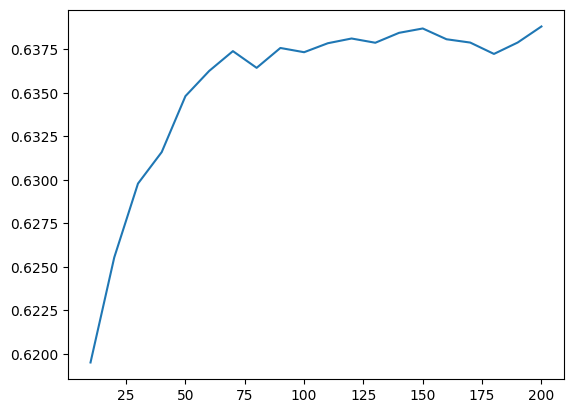

In [86]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [88]:
scores = []

for d in [5, 6]:
    for n in tqdm(range(10, 201, 10)):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

100%|██████████| 20/20 [07:55<00:00, 23.80s/it]


In [89]:
df_scores = pd.DataFrame(scores, columns=["max_depth", "n_estimators", "auc"])
df_scores.sort_values(by='auc', ascending=False)

,max_depth,n_estimators,auc
35,6,160,0.590068
36,6,170,0.589934
37,6,180,0.589907
38,6,190,0.589798
39,6,200,0.589771
28,6,90,0.589664
33,6,140,0.589663
19,5,200,0.589663
16,5,170,0.589636
32,6,130,0.589636


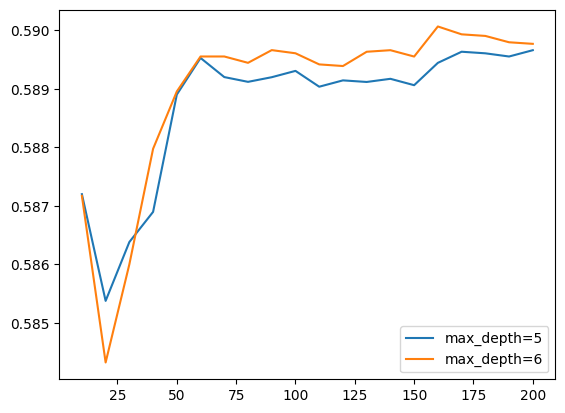

In [90]:
for d in [5, 6]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d'% d)
plt.legend()

In [92]:
max_depth = 6

In [96]:
scores = []

for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
    for n in tqdm(range(10, 201, 10)):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=s, random_state=42)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

100%|██████████| 20/20 [04:12<00:00, 12.61s/it]


In [97]:
df_scores = pd.DataFrame(scores, columns=["min_samples_leaf", "n_estimators", "auc"])
df_scores.sort_values(by='auc', ascending=False)

,min_samples_leaf,n_estimators,auc
101,20,20,0.602311
100,20,10,0.593942
124,100,50,0.593869
146,200,70,0.593576
147,200,80,0.593492
...,...,...,...
61,10,20,0.584678
1,1,20,0.584325
41,5,20,0.584157
21,2,20,0.584106


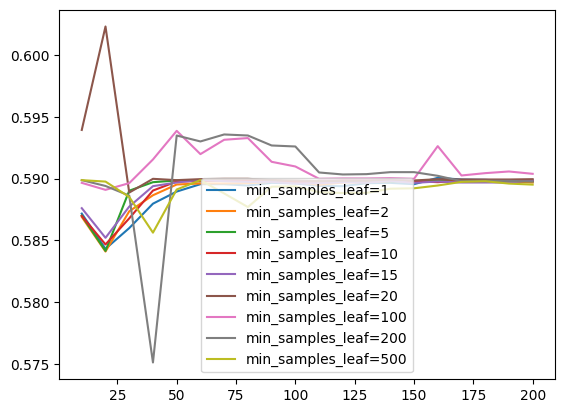

In [98]:
for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='min_samples_leaf=%d'% s)
plt.legend()

In [99]:
import xgboost as xgb

In [100]:
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(features))
dval = xgb.DMatrix(X_val, label=y_val, feature_names=list(features))

In [101]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [102]:
y_pred = model.predict(dval)

In [103]:
roc_auc_score(y_val, y_pred)

0.7266014890798154

In [104]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [114]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval=5, evals=watchlist)


In [115]:
s = output.stdout
line = s.split('\n')[0]
num_iter, train_auc, val_auc = line.split('\t')
int(num_iter.strip('[]'))

0

In [116]:
float(train_auc.split(":")[1])

0.72603

In [117]:
float(val_auc.split(':')[1])

0.72433

In [118]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(":")[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results


In [119]:
df_score = parse_xgb_output(output)

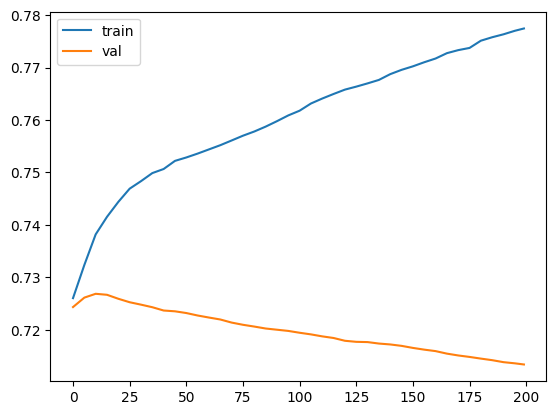

In [ ]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

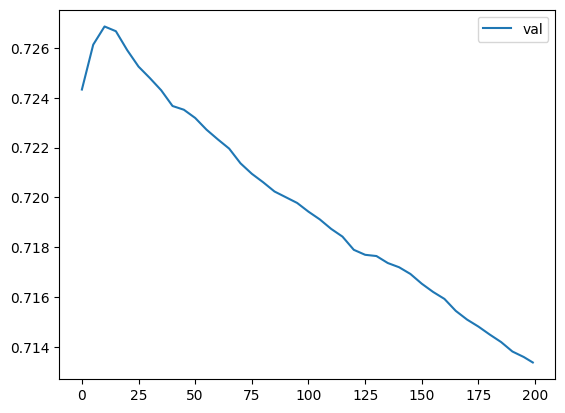

In [ ]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

In [122]:
scores = {}

In [ ]:
%%capture output

xgb_params = {
    'eta': 0.01, # 0.3, 1.0, 0.1, 0.05, 0.01
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval=5, evals=watchlist)

In [137]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)


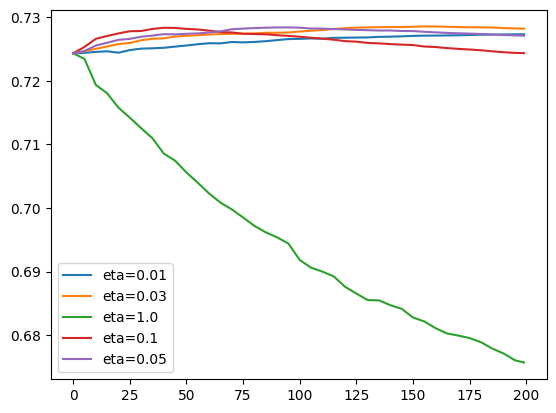

In [138]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)
plt.legend()

In [139]:
eta = 0.03
scores = {}

In [148]:
%%capture output

xgb_params = {
    'eta': eta,
    'max_depth': 10, # 3, 4, 6, 10
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval=5, evals=watchlist)

In [149]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)

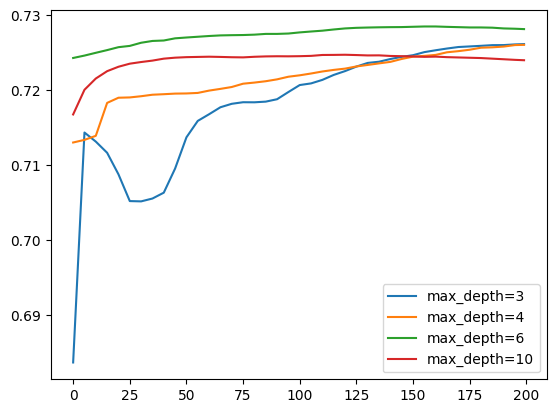

In [150]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)
plt.legend()

In [158]:
max_depth = 6
scores = {}

In [163]:
%%capture output

xgb_params = {
    'eta': eta,
    'max_depth': max_depth,
    'min_child_weight': 30, # 1, 10, 30

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval=5, evals=watchlist)

In [164]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)

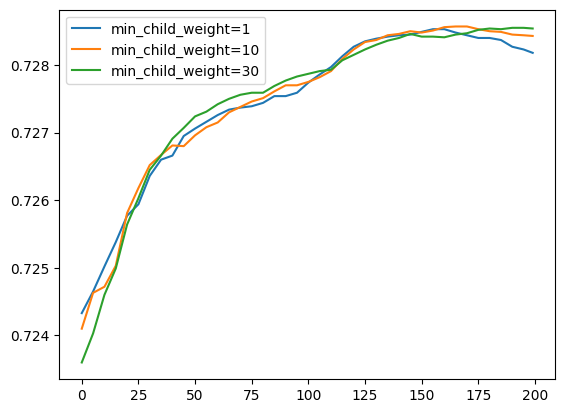

In [165]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)
plt.legend()

In [166]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.7285392493909105